### [Financial Distributions: Bell Curve to Reality](https://medium.com/@simplifiedzone/financial-distributions-from-the-bell-curve-to-reality-f032bb351f60)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_and_prepare_data(filepath):
    """
    Loads the financial data and selects the Dow Jones (DWJ) column.
    """
    try:
        df = pd.read_csv(filepath)
        # Convert Date to datetime for better plotting
        df['Date'] = pd.to_datetime(df['Date'])

        # We will focus on DWJ (Dow Jones) for this univariate analysis
        # Dropping NaNs if any exist to avoid computation errors
        returns = df['DWJ'].dropna()

        print(f"Data Loaded. N Observations: {len(returns)}")
        return returns
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

In [3]:
def analyze_normality(data, name="Asset"):
    """
    Performs visual and statistical tests for normality.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # 1. Histogram with Normal Overlay
    sns.histplot(data, kde=False, stat="density", bins=50, ax=axes[0], color='skyblue', label='Actual Data')

    # Generate normal curve based on data's mean and std
    mu, std = stats.norm.fit(data)
    xmin, xmax = axes[0].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    axes[0].plot(x, p, 'r', linewidth=2, label='Normal Distribution')
    axes[0].set_title(f'Distribution of {name} Returns vs. Normal')
    axes[0].legend()

    # 2. QQ Plot
    stats.probplot(data, dist="norm", plot=axes[1])
    axes[1].set_title(f'Q-Q Plot of {name} Returns')

    plt.tight_layout()
    plt.show()

    # 3. Statistical Tests
    print(f"\n--- Statistical Metrics for {name} ---")
    print(f"Mean: {np.mean(data):.6f}")
    print(f"Std Dev: {np.std(data):.6f}")

    # Skewness and Kurtosis
    skew = stats.skew(data)
    kurt = stats.kurtosis(data) # Fisher's kurtosis (excess kurtosis, normal = 0)

    print(f"Skewness: {skew:.4f} (Interpretation: {'Positive/Right' if skew > 0 else 'Negative/Left'} Skew)")
    print(f"Excess Kurtosis: {kurt:.4f} (Interpretation: {'Leptokurtic/Fat Tails' if kurt > 0 else 'Platykurtic/Thin Tails'})")

    # Shapiro-Wilk Test (Note: p-value may be inaccurate for N > 5000, but useful for illustration)
    stat, p_value = stats.shapiro(data)
    print(f"\n--- Shapiro-Wilk Test ---")
    print(f"Statistic: {stat:.4f}, p-value: {p_value:.4g}")
    if p_value < 0.05:
        print("Result: Reject Null Hypothesis. Data is NOT Normally distributed.")
    else:
        print("Result: Fail to reject Null Hypothesis. Data looks Normal.")

In [4]:
def fit_skewed_distributions(data, name="Asset"):
    """
    Fits and compares Normal vs. Skew-Normal distributions.
    """
    # Fit Normal
    mu_n, std_n = stats.norm.fit(data)

    # Fit Skew-Normal
    # skewnorm.fit returns (shape, loc, scale)
    a_sn, loc_sn, scale_sn = stats.skewnorm.fit(data)

    print(f"\n--- Fitting Models ---")
    print(f"Normal Fit -> Mean: {mu_n:.4f}, Std: {std_n:.4f}")
    print(f"Skew-Normal Fit -> Shape (alpha): {a_sn:.4f}, Loc: {loc_sn:.4f}, Scale: {scale_sn:.4f}")

    # Plotting comparison
    plt.figure(figsize=(10, 6))
    sns.histplot(data, stat="density", bins=50, color='lightgray', label='Actual Data', alpha=0.5)

    xmin, xmax = plt.xlim()
    x = np.linspace(xmin, xmax, 100)

    # Plot Normal PDF
    plt.plot(x, stats.norm.pdf(x, mu_n, std_n), 'r--', linewidth=2, label='Normal Fit')

    # Plot Skew-Normal PDF
    plt.plot(x, stats.skewnorm.pdf(x, a_sn, loc_sn, scale_sn), 'b-', linewidth=2, label='Skew-Normal Fit')

    plt.title(f"Model Comparison: Normal vs. Skew-Normal for {name}")
    plt.legend()
    plt.show()

Data Loaded. N Observations: 1507


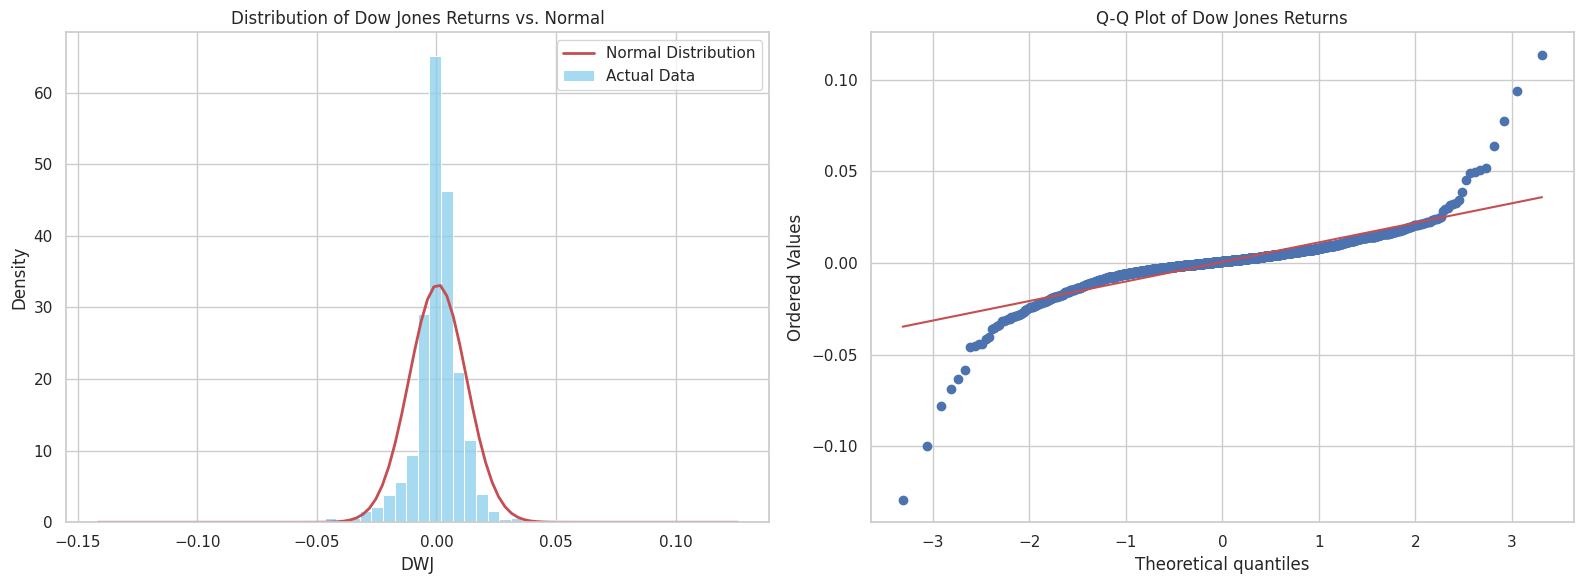


--- Statistical Metrics for Dow Jones ---
Mean: 0.000572
Std Dev: 0.012019
Skewness: -0.7046 (Interpretation: Negative/Left Skew)
Excess Kurtosis: 24.5489 (Interpretation: Leptokurtic/Fat Tails)

--- Shapiro-Wilk Test ---
Statistic: 0.7877, p-value: 1.821e-40
Result: Reject Null Hypothesis. Data is NOT Normally distributed.

--- Fitting Models ---
Normal Fit -> Mean: 0.0006, Std: 0.0120
Skew-Normal Fit -> Shape (alpha): -1.0222, Loc: 0.0087, Scale: 0.0145


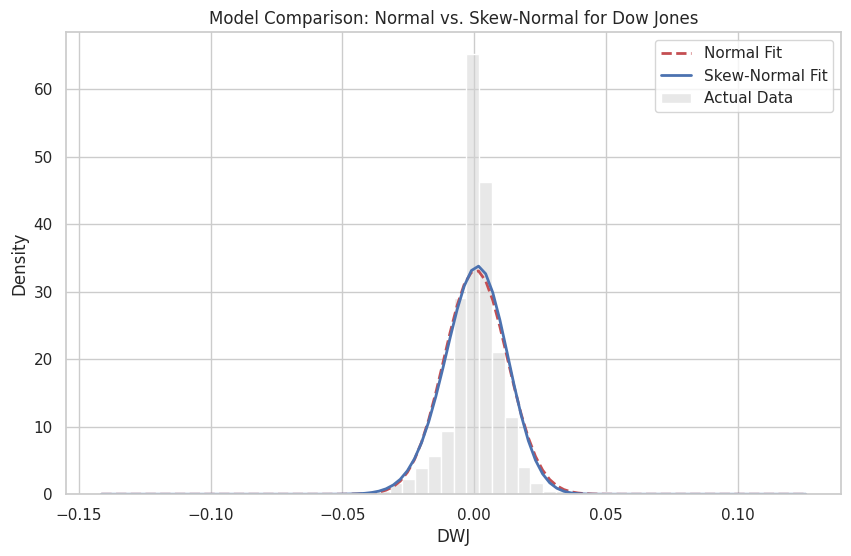

In [5]:
if __name__ == "__main__":
    # Update this path to your actual file location
    file_path = '/content/bell_curve_data.csv'

    dwj_data = load_and_prepare_data(file_path)

    if dwj_data is not None:
        analyze_normality(dwj_data, name="Dow Jones")
        fit_skewed_distributions(dwj_data, name="Dow Jones")